### An introduction to word embeddings

In [31]:
! pip install spacy gensim

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import os
import csv
import spacy

class Corpus(object):
    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")

    def __iter__(self):
        with open(self.filename,"r",encoding="utf-8") as i:
            reader=csv.reader(i,delimiter=",")
            for _, abstract in reader:
                tokens=[t.text.lower() for t in self.nlp(abstract)]
                yield tokens
documents=Corpus("arxiv.csv")



In [24]:
documents

#### tokenization

In [28]:
documents = list(documents)
documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [33]:
import gensim
model = gensim.models.Word2Vec(
    documents,
    vector_size=100,
    window=5,
    min_count=100,
)

### using word embeddings


In [34]:
model.wv["nlp"]

array([ 0.5287382 , -0.24447654,  2.5345325 , -0.9830683 ,  1.0703259 ,
       -0.31490877,  0.6149929 , -0.6938213 , -0.16979149,  1.6684242 ,
       -1.0836848 , -1.6061914 ,  1.8834894 ,  0.23964427, -0.8417296 ,
        0.4270832 , -0.5951704 ,  1.4719145 , -1.2081985 ,  2.709386  ,
       -0.6809613 , -0.59418935,  1.0584401 , -0.4652034 , -2.1894002 ,
       -3.0035663 ,  1.2337388 ,  0.93877083,  3.4784117 ,  0.42422214,
       -0.18619888,  0.3300023 ,  1.1220884 ,  0.60776836, -0.9799173 ,
       -1.4620899 ,  1.0011592 , -4.7911367 ,  0.60647964,  0.80629915,
       -1.5302135 , -0.9104074 ,  3.4815357 ,  0.63060284, -0.93676627,
        0.47987598,  3.148892  ,  0.88188446, -0.18692176, -2.451199  ,
        0.55552244,  0.8388415 ,  0.8645616 , -1.4105533 ,  2.450057  ,
        1.6479286 , -0.14981297, -0.12441112,  3.2637057 , -0.36644143,
        0.14828147,  3.643847  , -1.0810046 , -1.123486  , -0.54192626,
       -0.02805004, -0.69046086, -1.2182286 ,  1.5952854 , -0.75

In [37]:
print(model.wv.similarity("nmt","smt"))
print(model.wv.similarity("nmt","ner"))

0.65219516
0.39810038


In [38]:
model.wv.similar_by_word("bert",topn=10)

[('transformer', 0.7664577960968018),
 ('roberta', 0.7612863183021545),
 ('transformers', 0.7039494514465332),
 ('elmo', 0.6843253970146179),
 ('pretrained', 0.6765400767326355),
 ('mbert', 0.6612350344657898),
 ('gpt-2', 0.6079239249229431),
 ('xlnet', 0.6058611869812012),
 ('xlm', 0.5959838032722473),
 ('lstm', 0.5948240160942078)]

In [39]:
model.wv.most_similar(positive=["transformer","language"],negative=["model"],topn=10)

[('nlu', 0.5211532711982727),
 ('seq2seq', 0.48415037989616394),
 ('nlp', 0.4507802426815033),
 ('computer', 0.4392108917236328),
 ('nmt', 0.4317179024219513),
 ('languages', 0.42744913697242737),
 ('slu', 0.4126749634742737),
 ('nlg', 0.4093264639377594),
 ('pretrained', 0.38610348105430603),
 ('neural', 0.3783649504184723)]

In [40]:
model.wv.most_similar(positive=["tree"],topn=10)

[('trees', 0.7764774560928345),
 ('parse', 0.7130380868911743),
 ('constituency', 0.7072210907936096),
 ('recursive', 0.6871630549430847),
 ('constituent', 0.6289765238761902),
 ('dependency', 0.6283149123191833),
 ('grammars', 0.6217546463012695),
 ('syntax', 0.6186097264289856),
 ('formalism', 0.6115736365318298),
 ('hierarchical', 0.6003758907318115)]

In [41]:
print(model.wv.doesnt_match("lst cm gru svm transformer".split()))
print(model.wv.doesnt_match("bert word2vec gpt-2 roberta xlnet".split()))
print(model.wv.doesnt_match("word2vec bert glove fasttext elmo".split()))   


svm
word2vec
bert


### plotting embeddings

In [42]:
import matplotlib
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

target_word="bert"
selected_words=[w[0] for w in model.wv.most_similar(positive=[target_word],topn=200)]+[target_word]
embeddings=[model.wv[w] for w in selected_words]+ model.wv["bert"]

mapped_embeddings=TSNE(n_components=2,metric='cosine',init='pca').fit_transform(embeddings)

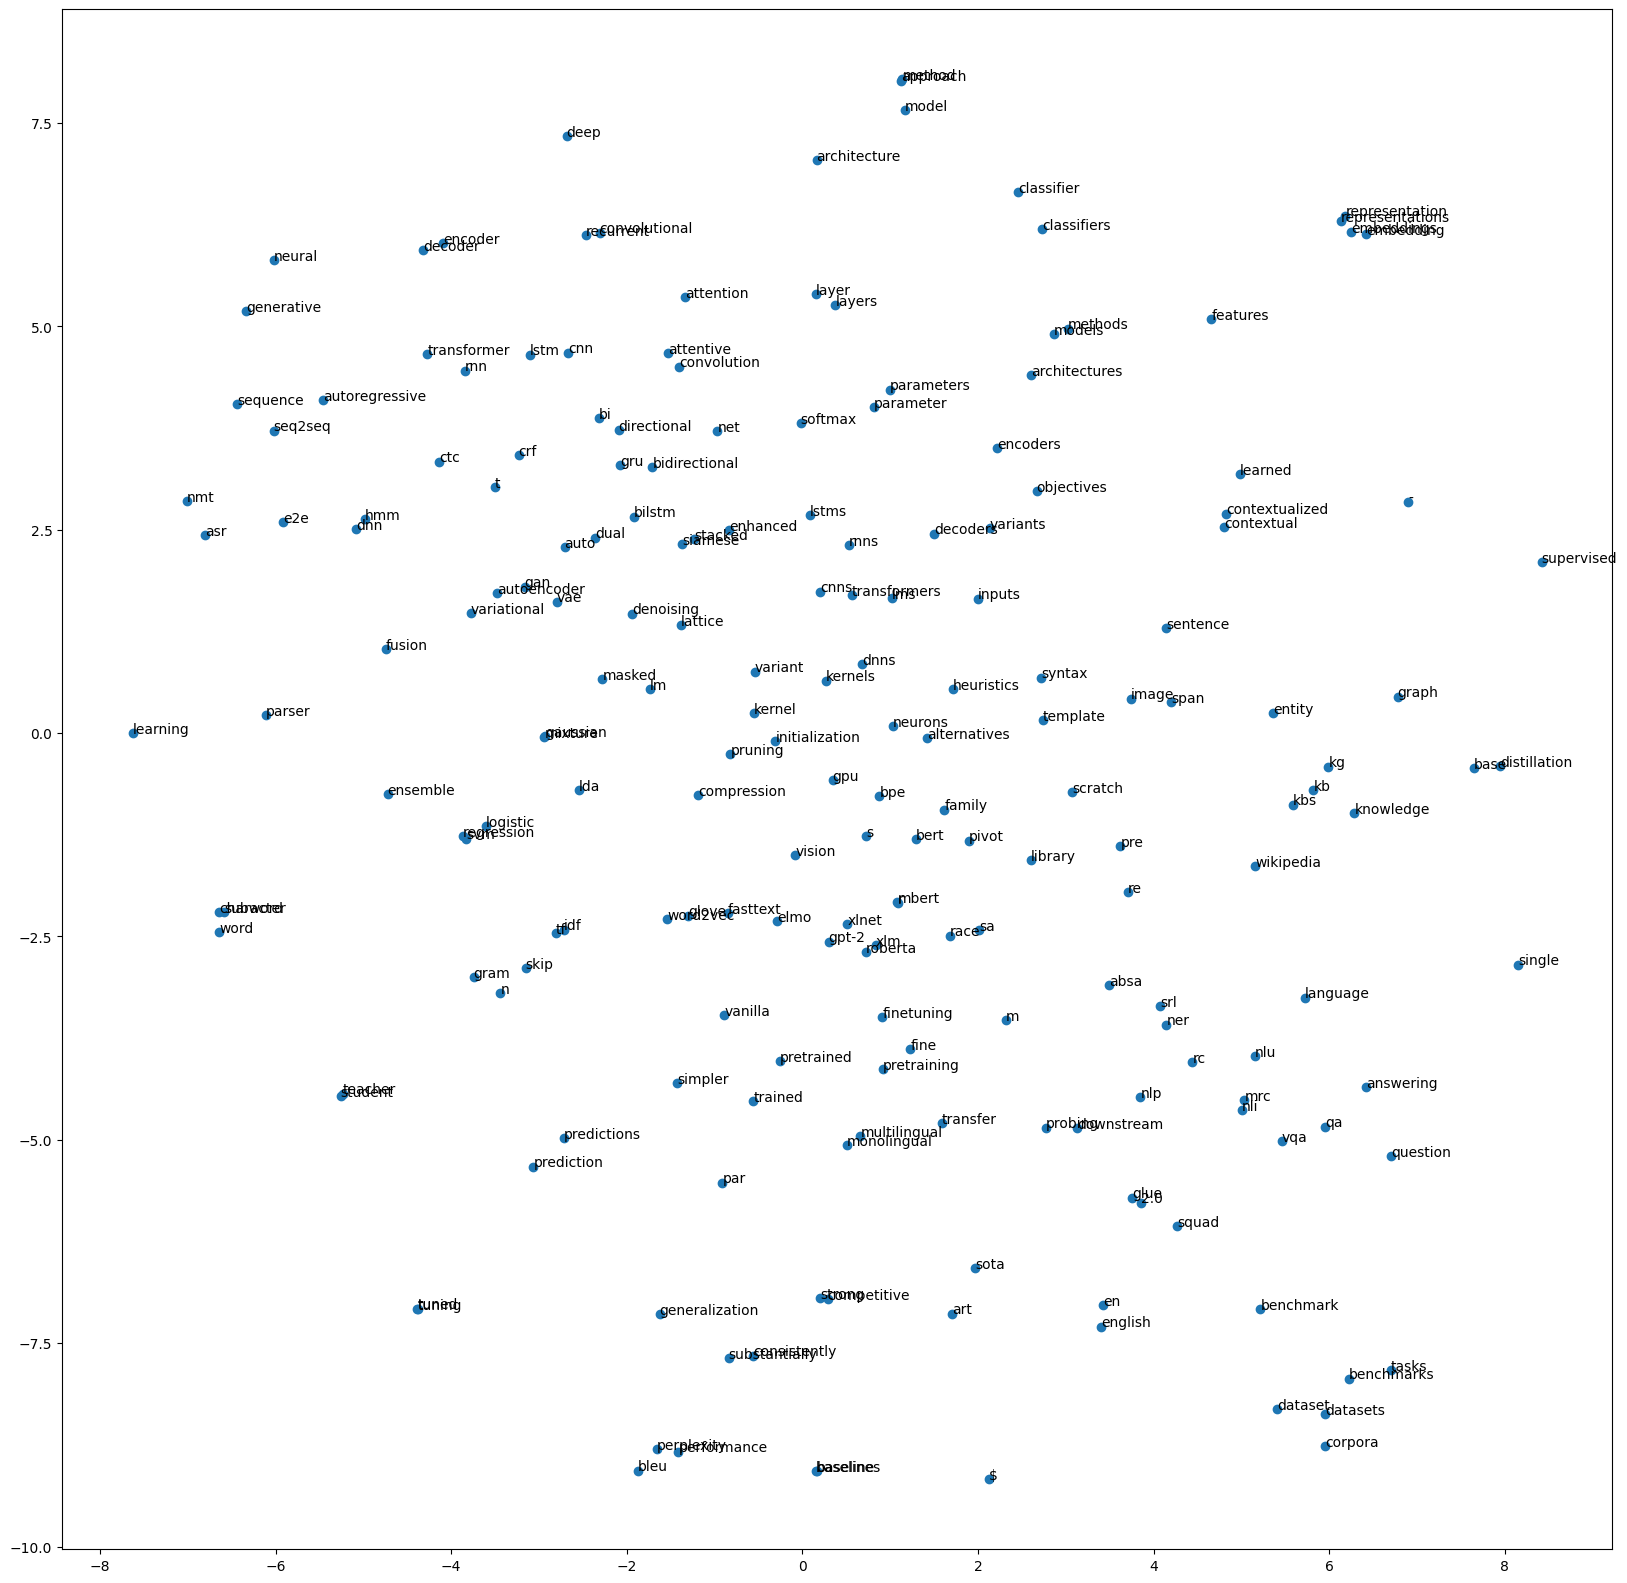

In [43]:
plt.figure(figsize=(20,20))
x=mapped_embeddings[:,0]
y=mapped_embeddings[:,1]
plt.scatter(x,y)

for i,txt in enumerate(selected_words):
    plt.annotate(txt,(x[i],y[i]))